In [1]:
import numpy as np
import pandas as pd

TRAIN = 'data/train.csv'
TEST = 'data/test.csv'

train = pd.read_csv(TRAIN)
test = pd.read_csv(TEST)

In [2]:
print(train.head(2))
print(test.head(2))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   

   Parch     Ticket     Fare Cabin Embarked  
0      0  A/5 21171   7.2500   NaN        S  
1      0   PC 17599  71.2833   C85        C  
   PassengerId  Pclass                              Name     Sex   Age  SibSp  \
0          892       3                  Kelly, Mr. James    male  34.5      0   
1          893       3  Wilkes, Mrs. James (Ellen Needs)  female  47.0      1   

   Parch  Ticket    Fare Cabin Embarked  
0      0  330911  7.8292   NaN        Q  
1      0  363272  7.0000   NaN        S  


In [3]:
n_train = train.shape[0]
n_test = test.shape[0]

print(train.shape)
print(test.shape)

(891, 12)
(418, 11)


In [4]:
print(train.isnull().sum())
print("---")
print(test.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
---
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [5]:
all_data = pd.concat([train, test], sort=False).reset_index(drop=True)
all_data.drop(columns=['Cabin', 'Ticket', 'PassengerId', 'Fare'], inplace=True)
PassengerId = test['PassengerId'].copy()

In [6]:
# Name processing
for idx, row in all_data.iterrows():
    name = row['Name']
    if 'Mr' in name:
        all_data.at[idx, 'Title'] = 'Mr'
    elif 'Mrs' in name:
        all_data.at[idx, 'Title'] = 'Mrs'
    elif 'Miss' in name:
        all_data.at[idx, 'Title'] = 'Miss'
    elif 'Master' in name:
        all_data.at[idx, 'Title'] = 'Master'
    else:
        all_data.at[idx, 'Title'] = 'NoTitle'

print(all_data['Title'].value_counts())

# Impute Age
all_data['Age'] = all_data.groupby(['Pclass', 'Sex', 'Title']).Age.apply(lambda x: x.fillna(x.median())).reset_index(drop=True)
print(all_data['Age'].value_counts())

# Family features
all_data['FamilySize'] = (all_data['SibSp'] + all_data['Parch'] + 1).astype(int).reset_index(drop=True)
all_data['IsAlone'] = (all_data['FamilySize'] <= 1).astype(int).reset_index(drop=True)

# One Hot Encoding
all_data['Sex'] = (all_data['Sex'] == 'male').astype(int).reset_index(drop=True)
all_data = pd.get_dummies(all_data, columns=['Embarked', 'Title'])

# Drop unused columns
all_data.drop(columns=['Name', 'SibSp', 'Parch'], inplace=True)

all_data.drop(columns=['FamilySize', 'IsAlone', 'FamilySize', 'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S'], inplace=True)

Title
Mr         959
Miss       258
Master      61
NoTitle     31
Name: count, dtype: int64
Age
26.0    166
18.0     86
30.0     55
24.0     47
42.0     45
       ... 
74.0      1
22.5      1
26.5      1
60.5      1
38.5      1
Name: count, Length: 98, dtype: int64


d:\VOAI25\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [7]:
print(all_data.head(1))

   Survived  Pclass  Sex   Age  Title_Master  Title_Miss  Title_Mr  \
0       0.0       3    1  58.0         False       False      True   

   Title_NoTitle  
0          False  


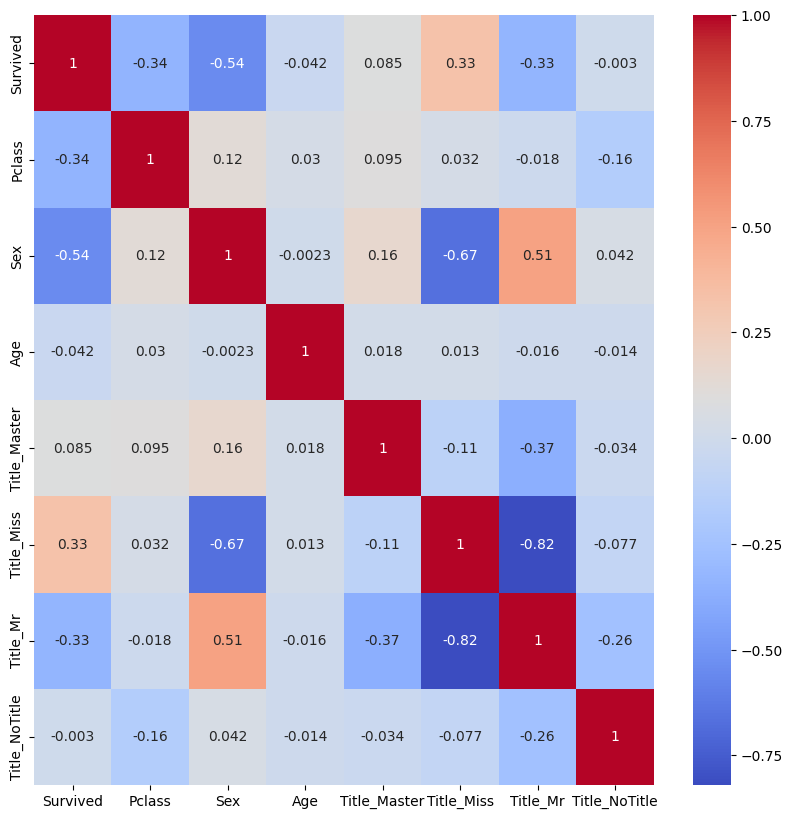

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.heatmap(all_data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [9]:
# sns.pairplot(
#     all_data, 
#     hue='Survived',
#     vars=['Age', 'Pclass', 'FamilySize', 'IsAlone']
# )
# plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

X_train = all_data.iloc[:n_train, :].copy()
X_test = all_data.iloc[n_train:, :].copy()
y_train = X_train['Survived'].copy()

X_train.drop(columns=['Survived'], inplace=True)
X_test.drop(columns=['Survived'], inplace=True)

print(X_train.shape)
print(X_train.head(2))
print(X_test.shape)
print(X_test.head(2))

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

(891, 7)
   Pclass  Sex   Age  Title_Master  Title_Miss  Title_Mr  Title_NoTitle
0       3    1  58.0         False       False      True          False
1       1    0  38.0         False       False      True          False
(418, 7)
     Pclass  Sex   Age  Title_Master  Title_Miss  Title_Mr  Title_NoTitle
891       3    1  26.0         False       False      True          False
892       3    0  59.0         False       False      True          False


In [11]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

cat = CatBoostClassifier(
    eval_metric='Accuracy',
    random_seed=42,
)

# # USING GRID SEARCH
# params = {
#     'learning_rate': [0.01, 0.02, 0.03, 0.04],
#     'depth': [3, 4, 5, 6, 7, 8],
#     'iterations': [300, 400, 500, 700, 900, 1000, 1200],
# }

# grid_search_cat = RandomizedSearchCV(
#     estimator=cat,
#     param_distributions=params,
#     scoring='accuracy',
#     cv=3,
#     n_jobs=-1,
#     verbose=1,
# ).fit(X_train, y_train)

# best_coarse = grid_search_cat.best_params_
# print('CatBoost Best Score',grid_search_cat.best_score_)
# print('CatBoost Best Parmas',grid_search_cat.best_params_)

In [12]:
params = {
    'learning_rate': [0.005, 0.01, 0.015, 0.02, 0.025],
    'depth': [6, 7, 8, 9],
    'iterations': [700, 800, 1000],
}

grid_search_cat = GridSearchCV(
    estimator=cat,
    param_grid=params,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1,
).fit(X_train, y_train)

cat_best = grid_search_cat.best_estimator_
print('CatBoost Best Score',grid_search_cat.best_score_)
print('CatBoost Best Parmas',grid_search_cat.best_params_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
0:	learn: 0.7867565	total: 111ms	remaining: 1m 28s
1:	learn: 0.7867565	total: 113ms	remaining: 45s
2:	learn: 0.7867565	total: 117ms	remaining: 31.1s
3:	learn: 0.7867565	total: 118ms	remaining: 23.5s
4:	learn: 0.7867565	total: 122ms	remaining: 19.4s
5:	learn: 0.7934905	total: 128ms	remaining: 17s
6:	learn: 0.7901235	total: 130ms	remaining: 14.7s
7:	learn: 0.7979798	total: 134ms	remaining: 13.3s
8:	learn: 0.7934905	total: 136ms	remaining: 11.9s
9:	learn: 0.8002245	total: 137ms	remaining: 10.8s
10:	learn: 0.8002245	total: 140ms	remaining: 10s
11:	learn: 0.8002245	total: 142ms	remaining: 9.32s
12:	learn: 0.8002245	total: 144ms	remaining: 8.7s
13:	learn: 0.7979798	total: 145ms	remaining: 8.16s
14:	learn: 0.7979798	total: 147ms	remaining: 7.69s
15:	learn: 0.7979798	total: 148ms	remaining: 7.27s
16:	learn: 0.7979798	total: 150ms	remaining: 6.92s
17:	learn: 0.7968575	total: 151ms	remaining: 6.58s
18:	learn: 0.7934905	total: 153ms	re

In [13]:
preds = cat_best.predict(X_test)

In [14]:
submission = pd.DataFrame({
    'PassengerId': PassengerId,
    'Survived': preds.astype(int)
})

submission.to_csv('submissions/baseline.csv', index=False)